# Ablation Study: Meta-Learner Comparison
## Two-Tier Stacking Ensemble — Indonesian Financial Sentiment Analysis

Notebook ini membandingkan kandidat meta-learner (Tier-1) untuk meng-aggregate prediksi OOF dari 3 base model BERT:
- **IndoBERT** (`indobenchmark/indobert-base-p2`)
- **IndoBERTweet** (`indolem/indobertweet-base-uncased`)
- **XLM-RoBERTa** (`xlm-roberta-base`)

**Evaluasi**: 5-Fold Stratified CV — metric utama = Macro F1 (dataset imbalanced: Positive > Neutral > Negative).

In [3]:
import warnings
warnings.filterwarnings("ignore")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.metrics import f1_score, accuracy_score, classification_report

import xgboost as xgb

SEED        = 42
N_FOLDS     = 5
OOF_DIR     = "results_run_20260514_192555"
RESULT_DIR  = "results_run_20260514_192555"
LABEL_MAP   = {"Negative": 0, "Neutral": 1, "Positive": 2}
LABEL_NAMES = ["Negative", "Neutral", "Positive"]


### 1. Load OOF Features & Labels

In [4]:
oof_indobert    = np.load(f"{OOF_DIR}/oof_indobert.npy")
oof_indoroberta = np.load(f"{OOF_DIR}/oof_indoroberta.npy")
oof_xlmr        = np.load(f"{OOF_DIR}/oof_xlmr.npy")
X               = np.load(f"{OOF_DIR}/oof_combined.npy")

# dataset_final_clean.csv mengandung data ganda akibat AA merge conflict pada git.
# Filter ke baris valid saja lalu ambil n_rows pertama yang sesuai jumlah OOF.
df_raw = pd.read_csv("DATASET/dataset_final_clean.csv")
df     = (df_raw[df_raw["sentiment"].isin(LABEL_MAP)]
            .reset_index(drop=True)
            .iloc[:len(X)])

assert len(df) == len(X), f"Mismatch: CSV {len(df)} rows vs OOF {len(X)} rows"

y = np.array([LABEL_MAP[s] for s in df["sentiment"]])

print(f"OOF directory  : {OOF_DIR}")
print(f"Feature matrix : {X.shape}  (samples x 9 OOF logits)")
print(f"IndoBERT       : {oof_indobert.shape}")
print(f"IndoBERTweet   : {oof_indoroberta.shape}")
print(f"XLM-RoBERTa    : {oof_xlmr.shape}")
print(f"Labels         : {y.shape}")
dist = dict(zip(*np.unique(y, return_counts=True)))
print(f"Label dist     : { {LABEL_NAMES[k]: int(v) for k, v in dist.items()} }")

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)


OOF directory  : results_run_20260514_192555
Feature matrix : (6120, 9)  (samples x 9 OOF logits)
IndoBERT       : (6120, 3)
IndoBERTweet   : (6120, 3)
XLM-RoBERTa    : (6120, 3)
Labels         : (6120,)
Label dist     : {'Negative': 1445, 'Neutral': 1825, 'Positive': 2850}


### 2. Soft Voting Baseline

Rata-rata probabilitas OOF dari 3 model BERT sebagai baseline sederhana tanpa training.
OOF logits sudah out-of-sample; per-fold std dihitung dengan mengevaluasi prediksi di tiap validation fold.

In [5]:
print("=" * 55)
print("SOFT VOTING BASELINE")
print("=" * 55)

avg_probs = (oof_indobert + oof_indoroberta + oof_xlmr) / 3.0
sv_preds  = np.argmax(avg_probs, axis=1)
sv_f1     = f1_score(y, sv_preds, average="macro")
sv_acc    = accuracy_score(y, sv_preds)

fold_f1s = [
    f1_score(y[val_idx], sv_preds[val_idx], average="macro")
    for _, val_idx in skf.split(avg_probs, y)
]
sv_std = np.std(fold_f1s)

print(f"Macro F1  : {sv_f1:.4f} +/- {sv_std:.4f}")
print(f"Accuracy  : {sv_acc:.4f}")
print()
print(classification_report(y, sv_preds, target_names=LABEL_NAMES))

sv_result = {
    "method": "Soft Voting", "val_f1": sv_f1, "std": sv_std,
    "val_acc": sv_acc, "train_f1": None, "gap": None, "best_params": "---",
}


SOFT VOTING BASELINE
Macro F1  : 0.7451 +/- 0.0201
Accuracy  : 0.7536

              precision    recall  f1-score   support

    Negative       0.70      0.76      0.73      1445
     Neutral       0.70      0.71      0.71      1825
    Positive       0.82      0.77      0.80      2850

    accuracy                           0.75      6120
   macro avg       0.74      0.75      0.75      6120
weighted avg       0.76      0.75      0.75      6120



### 3. Meta-Learner Comparison — Default Params (5-Fold CV)

Membandingkan 4 meta-learner dengan konfigurasi default menggunakan 5-Fold Stratified CV pada feature matrix OOF `X` (6120 x 9).

In [6]:
print("=" * 75)
print("DEFAULT META-LEARNER COMPARISON (5-Fold CV)")
print("=" * 75)

DEFAULT_MODELS = {
    "LR (default)": LogisticRegression(
        C=1.0, class_weight="balanced", max_iter=1000, random_state=SEED,
    ),
    "SVM (default)": SVC(
        C=1.0, class_weight="balanced", probability=True, random_state=SEED,
    ),
    "RF (default)": RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=SEED, n_jobs=-1,
    ),
    "XGB (default)": xgb.XGBClassifier(
        n_estimators=200, max_depth=4, eval_metric="mlogloss",
        random_state=SEED, n_jobs=-1, verbosity=0,
    ),
}

print(f"{'Method':<22} {'Val F1':>8} {'+/-std':>7} {'Accuracy':>9} {'Train F1':>9} {'Gap':>8}")
print("-" * 70)

default_results = {}
for name, clf in DEFAULT_MODELS.items():
    cv_res = cross_validate(
        clf, X, y, cv=skf,
        scoring={"macro_f1": "f1_macro", "accuracy": "accuracy"},
        return_train_score=True,
        n_jobs=-1,
    )
    val_f1   = cv_res["test_macro_f1"].mean()
    val_std  = cv_res["test_macro_f1"].std()
    val_acc  = cv_res["test_accuracy"].mean()
    train_f1 = cv_res["train_macro_f1"].mean()
    gap      = train_f1 - val_f1
    default_results[name] = {
        "method": name, "val_f1": val_f1, "std": val_std,
        "val_acc": val_acc, "train_f1": train_f1, "gap": gap,
        "best_params": "default",
    }
    print(f"{name:<22} {val_f1:>8.4f} {val_std:>7.4f} {val_acc:>9.4f} {train_f1:>9.4f} {gap:>8.4f}")


DEFAULT META-LEARNER COMPARISON (5-Fold CV)
Method                   Val F1  +/-std  Accuracy  Train F1      Gap
----------------------------------------------------------------------
LR (default)             0.7424  0.0186    0.7505    0.7430   0.0006
SVM (default)            0.7374  0.0180    0.7440    0.7462   0.0088
RF (default)             0.7297  0.0159    0.7413    0.9986   0.2689
XGB (default)            0.7159  0.0172    0.7281    0.9693   0.2534


### 4. Hyperparameter Tuning (RandomizedSearchCV, n_iter=20, cv=5)

Mencari konfigurasi terbaik untuk masing-masing meta-learner.

> **Note (LR)**: solver dikunci ke `saga` karena mendukung penalty L1 dan L2. `lbfgs` hanya mendukung L2 sehingga kombinasi `(l1, lbfgs)` tidak valid.

In [7]:
print("=" * 70)
print("HYPERPARAMETER TUNING (RandomizedSearchCV, n_iter=20, cv=5)")
print("=" * 70)

PARAM_GRIDS = {
    "LR (tuned)": {
        "estimator": LogisticRegression(
            class_weight="balanced", max_iter=2000,
            random_state=SEED, solver="saga",
        ),
        "params": {
            "C"      : [0.001, 0.01, 0.1, 1.0, 5.0, 10.0],
            "penalty": ["l1", "l2"],
        },
    },
    "SVM (tuned)": {
        "estimator": SVC(
            class_weight="balanced", probability=True, random_state=SEED,
        ),
        "params": {
            "C"     : [0.1, 1.0, 10.0, 100.0],
            "kernel": ["rbf", "linear"],
            "gamma" : ["scale", "auto"],
        },
    },
    "RF (tuned)": {
        "estimator": RandomForestClassifier(
            class_weight="balanced", random_state=SEED, n_jobs=-1,
        ),
        "params": {
            "n_estimators"    : [100, 200, 300, 500],
            "max_depth"       : [5, 10, 15, None],
            "min_samples_leaf": [1, 2, 5],
            "max_features"    : ["sqrt", "log2"],
        },
    },
    "XGB (tuned)": {
        "estimator": xgb.XGBClassifier(
            eval_metric="mlogloss", random_state=SEED, n_jobs=-1, verbosity=0,
        ),
        "params": {
            "n_estimators"  : [100, 200, 300],
            "max_depth"     : [3, 4, 5],
            "learning_rate" : [0.01, 0.05, 0.1],
            "reg_alpha"     : [0.0, 0.1, 1.0],
            "reg_lambda"    : [0.5, 1.0, 2.0],
        },
    },
}

tuned_results = {}
for name, cfg in PARAM_GRIDS.items():
    print(f"\n[{name}] tuning...", flush=True)
    search = RandomizedSearchCV(
        cfg["estimator"], cfg["params"],
        n_iter=20, cv=skf,
        scoring="f1_macro",
        refit=True,
        random_state=SEED,
        n_jobs=-1,
        return_train_score=True,
    )
    search.fit(X, y)

    best_idx  = search.best_index_
    val_f1    = float(search.cv_results_["mean_test_score"][best_idx])
    val_std   = float(search.cv_results_["std_test_score"][best_idx])
    train_f1  = float(search.cv_results_["mean_train_score"][best_idx])
    gap       = train_f1 - val_f1

    acc_cv  = cross_validate(
        search.best_estimator_, X, y, cv=skf,
        scoring="accuracy", n_jobs=-1,
    )
    val_acc = float(acc_cv["test_score"].mean())

    print(f"  Val F1   : {val_f1:.4f} +/- {val_std:.4f}")
    print(f"  Train F1 : {train_f1:.4f}  |  Gap: {gap:.4f}")
    print(f"  Accuracy : {val_acc:.4f}")
    print(f"  Best params: {search.best_params_}")

    tuned_results[name] = {
        "method": name, "val_f1": val_f1, "std": val_std,
        "val_acc": val_acc, "train_f1": train_f1, "gap": gap,
        "best_params": search.best_params_,
    }

print("\nTuning selesai.")


HYPERPARAMETER TUNING (RandomizedSearchCV, n_iter=20, cv=5)

[LR (tuned)] tuning...
  Val F1   : 0.7432 +/- 0.0193
  Train F1 : 0.7438  |  Gap: 0.0006
  Accuracy : 0.7511
  Best params: {'penalty': 'l2', 'C': 0.001}

[SVM (tuned)] tuning...
  Val F1   : 0.7400 +/- 0.0184
  Train F1 : 0.7464  |  Gap: 0.0064
  Accuracy : 0.7469
  Best params: {'kernel': 'rbf', 'gamma': 'auto', 'C': 100.0}

[RF (tuned)] tuning...
  Val F1   : 0.7394 +/- 0.0149
  Train F1 : 0.8671  |  Gap: 0.1278
  Accuracy : 0.7469
  Best params: {'n_estimators': 100, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': None}

[XGB (tuned)] tuning...
  Val F1   : 0.7451 +/- 0.0153
  Train F1 : 0.7581  |  Gap: 0.0131
  Accuracy : 0.7567
  Best params: {'reg_lambda': 0.5, 'reg_alpha': 1.0, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.01}

Tuning selesai.


### 5. Final Comparison Table & Paper Summary

In [8]:
all_results = (
    [sv_result]
    + list(default_results.values())
    + list(tuned_results.values())
)

print("=" * 90)
print("FINAL COMPARISON TABLE")
print("=" * 90)
header = f"{'Method':<22} {'Val F1':>8} {'+/-std':>7} {'Accuracy':>9} {'Train F1':>9} {'Gap':>8}"
print(header)
print("-" * 70)

for r in all_results:
    gap_str   = f"{r['gap']:>8.4f}" if r["gap"] is not None else "       --"
    train_str = f"{r['train_f1']:>9.4f}" if r["train_f1"] is not None else "        --"
    print(f"{r['method']:<22} {r['val_f1']:>8.4f} {r['std']:>7.4f} {r['val_acc']:>9.4f} {train_str} {gap_str}")

best = max(all_results, key=lambda r: r["val_f1"])
lr_def_f1 = default_results["LR (default)"]["val_f1"]

print()
print("=" * 55)
print("ABLATION STUDY: META-LEARNER COMPARISON")
print("=" * 55)
print(f"Best Meta-Learner : {best['method']}")
print(f"Best Params       : {best['best_params']}")
print(f"CV Macro F1       : {best['val_f1']:.4f} +/- {best['std']:.4f}")
print(f"vs Soft Voting    : {best['val_f1'] - sv_result['val_f1']:+.4f}")
print(f"vs LR Default     : {best['val_f1'] - lr_def_f1:+.4f}")
print("=" * 55)


FINAL COMPARISON TABLE
Method                   Val F1  +/-std  Accuracy  Train F1      Gap
----------------------------------------------------------------------
Soft Voting              0.7451  0.0201    0.7536         --        --
LR (default)             0.7424  0.0186    0.7505    0.7430   0.0006
SVM (default)            0.7374  0.0180    0.7440    0.7462   0.0088
RF (default)             0.7297  0.0159    0.7413    0.9986   0.2689
XGB (default)            0.7159  0.0172    0.7281    0.9693   0.2534
LR (tuned)               0.7432  0.0193    0.7511    0.7438   0.0006
SVM (tuned)              0.7400  0.0184    0.7469    0.7464   0.0064
RF (tuned)               0.7394  0.0149    0.7469    0.8671   0.1278
XGB (tuned)              0.7451  0.0153    0.7567    0.7581   0.0131

ABLATION STUDY: META-LEARNER COMPARISON
Best Meta-Learner : Soft Voting
Best Params       : ---
CV Macro F1       : 0.7451 +/- 0.0201
vs Soft Voting    : +0.0000
vs LR Default     : +0.0027


### 6. Visualization

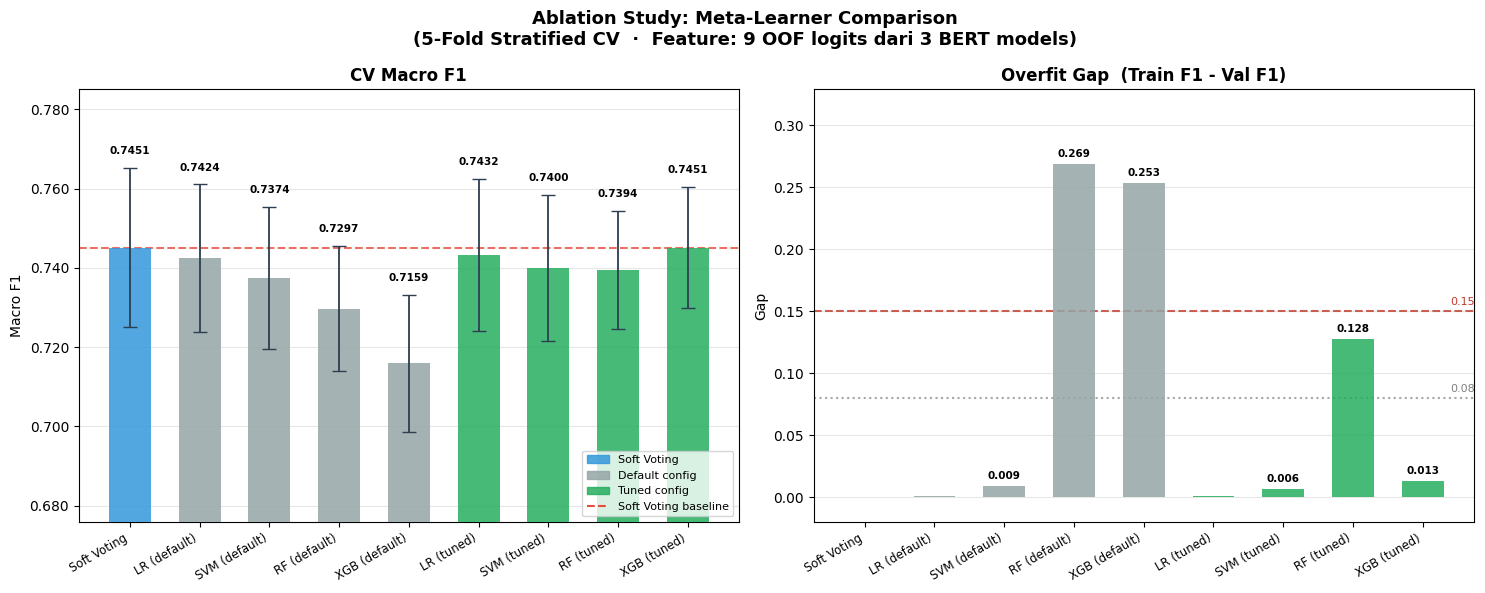

Saved -> results_run_20260514_192555/ablation_metalearner.png


In [9]:
Path(RESULT_DIR).mkdir(exist_ok=True)

methods = [r["method"] for r in all_results]
f1s     = [r["val_f1"] for r in all_results]
stds    = [r["std"] for r in all_results]
gaps    = [r["gap"] if r["gap"] is not None else 0.0 for r in all_results]

colors = []
for r in all_results:
    if r["method"] == "Soft Voting":
        colors.append("#3498db")
    elif "(default)" in r["method"]:
        colors.append("#95a5a6")
    else:
        colors.append("#27ae60")

x = np.arange(len(methods))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(
    "Ablation Study: Meta-Learner Comparison\n"
    "(5-Fold Stratified CV  ·  Feature: 9 OOF logits dari 3 BERT models)",
    fontsize=13, fontweight="bold",
)

# Panel kiri — CV Macro F1
bars1 = ax1.bar(x, f1s, color=colors, alpha=0.85, zorder=3, width=0.6)
ax1.errorbar(x, f1s, yerr=stds, fmt="none", color="#2c3e50",
             capsize=5, linewidth=1.3, zorder=4)
ax1.axhline(sv_result["val_f1"], color="#e74c3c", linestyle="--",
            linewidth=1.5, alpha=0.8)
ax1.set_title("CV Macro F1", fontweight="bold")
ax1.set_xticks(x)
ax1.set_xticklabels(methods, rotation=30, ha="right", fontsize=8.5)
ax1.set_ylabel("Macro F1")
f1_min = max(0.60, min(f1s) - 0.04)
ax1.set_ylim(f1_min, max(f1s) + 0.04)
ax1.grid(axis="y", alpha=0.3, zorder=0)
ax1.yaxis.set_major_formatter(plt.FormatStrFormatter("%.3f"))
for bar, v, s in zip(bars1, f1s, stds):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+s+0.003,
             f"{v:.4f}", ha="center", va="bottom", fontsize=7.5, fontweight="bold")

# Panel kanan — Overfit Gap
bars2 = ax2.bar(x, gaps, color=colors, alpha=0.85, zorder=3, width=0.6)
ax2.axhline(0.15, color="#c0392b", linestyle="--", lw=1.5, alpha=0.8)
ax2.axhline(0.08, color="gray",    linestyle=":",  lw=1.5, alpha=0.7)
ax2.text(len(methods) - 0.6, 0.155, "0.15", fontsize=8, color="#c0392b")
ax2.text(len(methods) - 0.6, 0.085, "0.08", fontsize=8, color="gray")
ax2.set_title("Overfit Gap  (Train F1 - Val F1)", fontweight="bold")
ax2.set_xticks(x)
ax2.set_xticklabels(methods, rotation=30, ha="right", fontsize=8.5)
ax2.set_ylabel("Gap")
ax2.set_ylim(-0.02, max(gaps) + 0.06)
ax2.grid(axis="y", alpha=0.3, zorder=0)
for bar, v in zip(bars2, gaps):
    if v > 0.001:
        ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004,
                 f"{v:.3f}", ha="center", va="bottom", fontsize=7.5, fontweight="bold")

# Legend
p_sv  = mpatches.Patch(color="#3498db", alpha=0.85, label="Soft Voting")
p_def = mpatches.Patch(color="#95a5a6", alpha=0.85, label="Default config")
p_tun = mpatches.Patch(color="#27ae60", alpha=0.85, label="Tuned config")
p_bl  = plt.Line2D([0],[0], color="#e74c3c", linestyle="--", label="Soft Voting baseline")
ax1.legend(handles=[p_sv, p_def, p_tun, p_bl], fontsize=8, loc="lower right")

plt.tight_layout()
out_png = f"{RESULT_DIR}/ablation_metalearner.png"
fig.savefig(out_png, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {out_png}")


In [10]:
out_json = f"{RESULT_DIR}/ablation_metalearner.json"

def to_serializable(v):
    if isinstance(v, (float, int)):
        return round(v, 4)
    if hasattr(v, "item"):  # numpy scalar
        return round(v.item(), 4)
    return v

save_data = {
    "timestamp": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S"),
    "oof_dir"  : OOF_DIR,
    "n_folds"  : N_FOLDS,
    "results"  : [
        {k: to_serializable(v) for k, v in r.items()}
        for r in all_results
    ],
}
with open(out_json, "w", encoding="utf-8") as f:
    json.dump(save_data, f, indent=2, ensure_ascii=False, default=str)
print(f"Saved -> {out_json}")


Saved -> results_run_20260514_192555/ablation_metalearner.json


### 7. Confusion Matrix — XGBoost (tuned)

Computing OOF predictions for XGB (tuned)... done


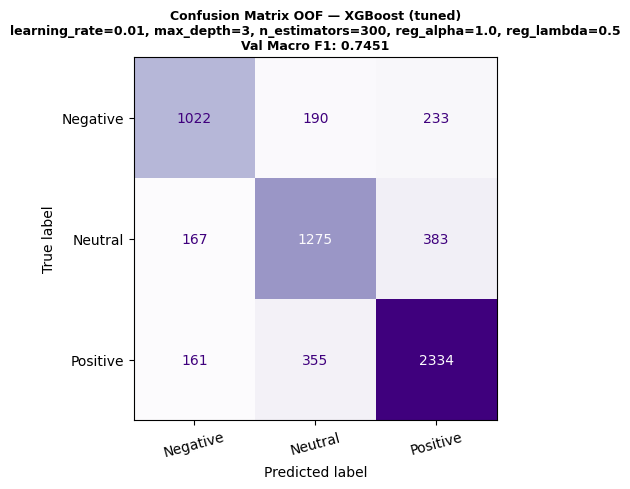

Saved -> results_run_20260514_192555/ablation_xgb_confusion_matrix.png


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict

# Rebuild best XGB dari params hasil tuning
xgb_best_params = tuned_results["XGB (tuned)"]["best_params"]
xgb_best = xgb.XGBClassifier(
    **xgb_best_params,
    eval_metric="mlogloss", random_state=SEED, n_jobs=-1, verbosity=0,
)

# OOF predictions dengan best estimator
print("Computing OOF predictions for XGB (tuned)...", end=" ", flush=True)
y_oof_xgb = cross_val_predict(xgb_best, X, y, cv=skf, n_jobs=-1)
print("done")

cm   = confusion_matrix(y, y_oof_xgb)
f1   = tuned_results["XGB (tuned)"]["val_f1"]
params_str = ", ".join(f"{k}={v}" for k, v in sorted(xgb_best_params.items()))

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABEL_NAMES)
disp.plot(ax=ax, colorbar=False, cmap="Purples")
ax.set_title(
    f"Confusion Matrix OOF - XGBoost (tuned)\n"
    f"{params_str}\n"
    f"Val Macro F1: {f1:.4f}",
    fontsize=9, fontweight="bold",
)
ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
out_cm = f"{RESULT_DIR}/ablation_xgb_confusion_matrix.png"
fig.savefig(out_cm, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {out_cm}")


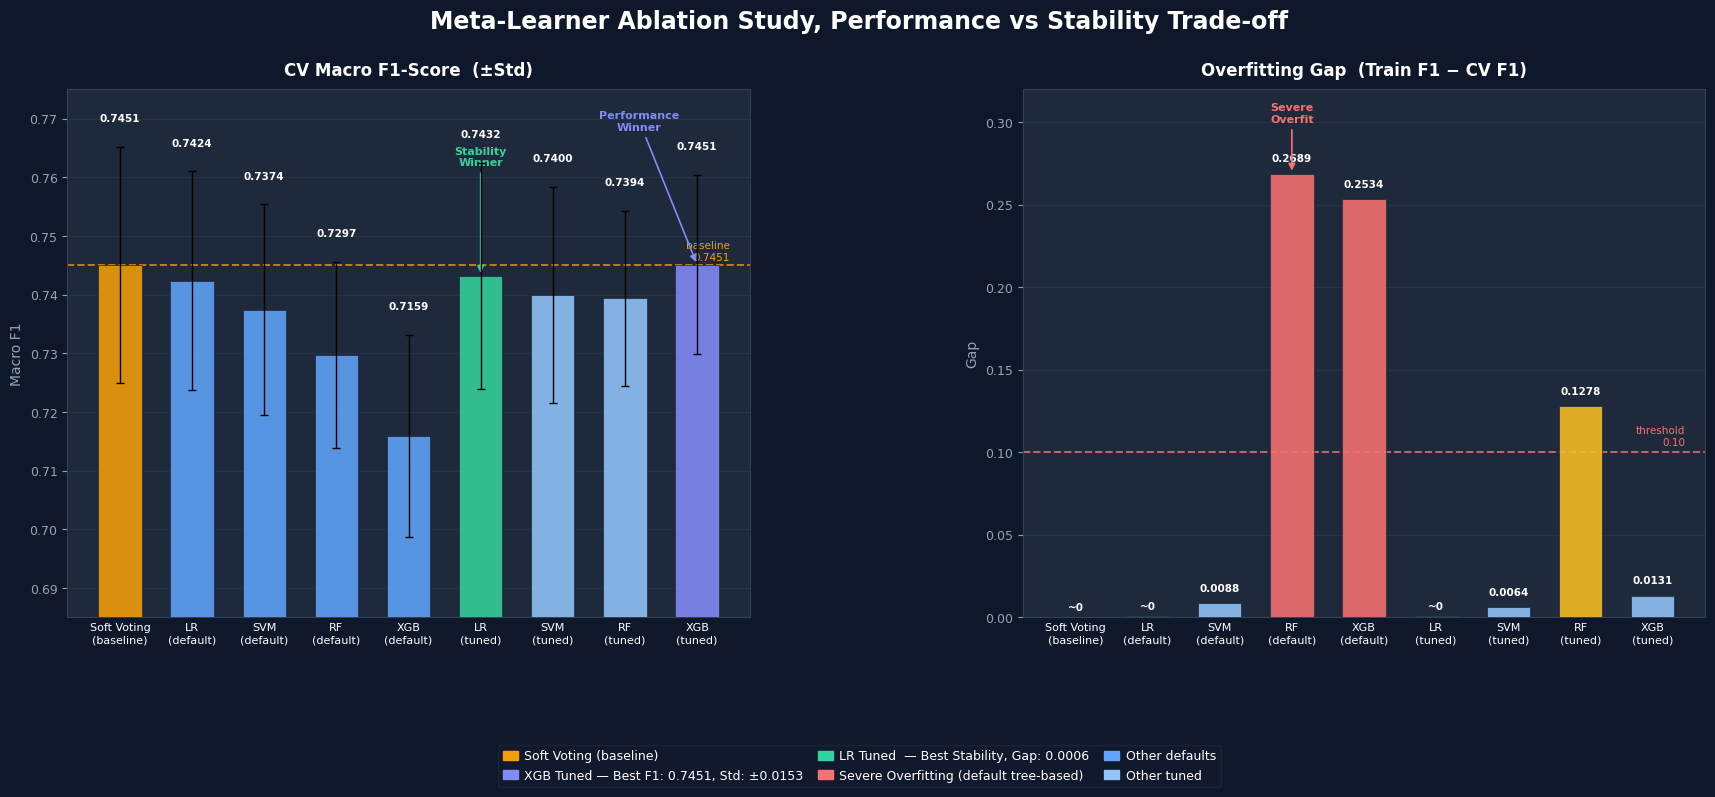

Done! Saved to ablation_chart.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

methods = [
    "Soft Voting\n(baseline)",
    "LR\n(default)",
    "SVM\n(default)",
    "RF\n(default)",
    "XGB\n(default)",
    "LR\n(tuned)",
    "SVM\n(tuned)",
    "RF\n(tuned)",
    "XGB\n(tuned)",
]

f1  = [0.7451, 0.7424, 0.7374, 0.7297, 0.7159, 0.7432, 0.7400, 0.7394, 0.7451]
std = [0.0201, 0.0186, 0.0180, 0.0159, 0.0172, 0.0193, 0.0184, 0.0149, 0.0153]
gap = [0,      0.0006, 0.0088, 0.2689, 0.2534, 0.0006, 0.0064, 0.1278, 0.0131]

x = np.arange(len(methods))
BAR_W = 0.6


colors_f1 = [
    "#F59E0B",  # Soft Voting
    "#60A5FA",  # LR default
    "#60A5FA",  # SVM default
    "#60A5FA",  # RF default
    "#60A5FA",  # XGB default
    "#34D399",  # LR tuned  — stability winner
    "#93C5FD",  # SVM tuned
    "#93C5FD",  # RF tuned
    "#818CF8",  # XGB tuned — performance winner
]

colors_gap = [
    "#94A3B8",  # Soft Voting
    "#34D399",  # LR default
    "#93C5FD",  # SVM default
    "#F87171",  # RF default  — severe overfit
    "#F87171",  # XGB default — severe overfit
    "#34D399",  # LR tuned
    "#93C5FD",  # SVM tuned
    "#FBBF24",  # RF tuned
    "#93C5FD",  # XGB tuned
]


fig = plt.figure(figsize=(18, 8), facecolor="#0F172A")
fig.suptitle(
    "Meta-Learner Ablation Study, Performance vs Stability Trade-off",
    fontsize=17, fontweight="bold", color="white", y=0.98
)

gs  = GridSpec(1, 2, figure=fig, wspace=0.40,
               left=0.06, right=0.97, top=0.88, bottom=0.22)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

# ── helper: style axes ──────────────────────────────────────
def style_ax(ax, title, ylabel):
    ax.set_facecolor("#1E293B")
    ax.set_title(title, color="white", fontsize=12,
                 fontweight="bold", pad=10)
    ax.set_ylabel(ylabel, color="#94A3B8", fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(methods, color="white", fontsize=8,
                       linespacing=1.3)
    ax.tick_params(axis="y", colors="#94A3B8", labelsize=9)
    ax.tick_params(axis="x", length=0)
    for spine in ax.spines.values():
        spine.set_color("#334155")
    ax.grid(axis="y", color="#334155", alpha=0.4, zorder=0)


style_ax(ax1, "CV Macro F1-Score  (±Std)", "Macro F1")

bars1 = ax1.bar(
    x, f1, width=BAR_W,
    color=colors_f1, alpha=0.88,
    yerr=std, capsize=3,
    error_kw={"color": "white", "linewidth": 1, "capthick": 1},
    edgecolor="#1E293B", linewidth=0.6, zorder=3
)

# Baseline reference line
ax1.axhline(y=0.7451, color="#F59E0B", linestyle="--",
            linewidth=1.4, alpha=0.75, zorder=2)
ax1.text(8.45, 0.7455, "baseline\n0.7451",
         color="#F59E0B", fontsize=7.5, va="bottom", ha="right")

ax1.set_ylim(0.685, 0.775)

# Value labels — placed just above error bar cap
for i, (val, s) in enumerate(zip(f1, std)):
    ax1.text(i, val + s + 0.004, f"{val:.4f}",
             ha="center", va="bottom",
             fontsize=7.5, color="white", fontweight="bold")

# Winner annotations — use axes fraction to avoid overlap
ax1.annotate(
    "Stability\nWinner",
    xy=(5, f1[5]), xytext=(5, 0.762),
    ha="center", fontsize=8, color="#34D399", fontweight="bold",
    arrowprops=dict(arrowstyle="-|>", color="#34D399",
                    lw=1.2, mutation_scale=10)
)
ax1.annotate(
    "Performance\nWinner",
    xy=(8, f1[8]), xytext=(7.2, 0.768),
    ha="center", fontsize=8, color="#818CF8", fontweight="bold",
    arrowprops=dict(arrowstyle="-|>", color="#818CF8",
                    lw=1.2, mutation_scale=10)
)


style_ax(ax2, "Overfitting Gap  (Train F1 − CV F1)", "Gap")

bars2 = ax2.bar(
    x, gap, width=BAR_W,
    color=colors_gap, alpha=0.88,
    edgecolor="#1E293B", linewidth=0.6, zorder=3
)

# Danger threshold
ax2.axhline(y=0.1, color="#F87171", linestyle="--",
            linewidth=1.4, alpha=0.8, zorder=2)
ax2.text(8.45, 0.103, "threshold\n0.10",
         color="#F87171", fontsize=7.5, va="bottom", ha="right")

ax2.set_ylim(0, 0.32)

# Value labels — skip near-zero to avoid clutter
for i, (bar, val) in enumerate(zip(bars2, gap)):
    label = f"{val:.4f}" if val >= 0.005 else "~0"
    offset = 0.006 if val >= 0.005 else 0.003
    ax2.text(bar.get_x() + bar.get_width() / 2,
             val + offset, label,
             ha="center", va="bottom",
             fontsize=7.5, color="white", fontweight="bold")

# Annotate severe overfit zone
ax2.annotate(
    "Severe\nOverfit",
    xy=(3, gap[3]), xytext=(3, 0.30),
    ha="center", fontsize=8, color="#F87171", fontweight="bold",
    arrowprops=dict(arrowstyle="-|>", color="#F87171",
                    lw=1.2, mutation_scale=10)
)


legend_items = [
    mpatches.Patch(color="#F59E0B", label="Soft Voting (baseline)"),
    mpatches.Patch(color="#818CF8", label="XGB Tuned — Best F1: 0.7451, Std: ±0.0153"),
    mpatches.Patch(color="#34D399", label="LR Tuned  — Best Stability, Gap: 0.0006"),
    mpatches.Patch(color="#F87171", label="Severe Overfitting (default tree-based)"),
    mpatches.Patch(color="#60A5FA", label="Other defaults"),
    mpatches.Patch(color="#93C5FD", label="Other tuned"),
]

fig.legend(
    handles=legend_items,
    loc="lower center",
    ncol=3,
    fontsize=9,
    framealpha=0.2,
    facecolor="#1E293B",
    edgecolor="#475569",
    labelcolor="white",
    bbox_to_anchor=(0.5, 0.00),
    handlelength=1.2,
    handletextpad=0.5,
    columnspacing=1.2,
)

plt.savefig("ablation_chart.png", dpi=180,
            bbox_inches="tight", facecolor="#0F172A")
plt.show()
print("Done! Saved to ablation_chart.png")